# A Project for You



## Instructions

For this, you'll need to make several classification models and select the best one. Your notebook will illustrate and explain this process. 

### Detailed Requirements

<ol>
<li> You need one model per person. Decide on a slightly different approach for each person - you can change things like varaibles used, preparation, Regression or Bayes models, and othe things like that.</li>
<li> For each model, you must: </li>
    <ol>
    <li> Create a predictive model. </li>
    <li> Evaluate its performance. </li>
    <li> Create a markdown cell that explains your model choice and evaluation. </li>
    </ol>
<li> Overall, as a team, your team will select the best model from the selection. </li>
<li> <b> This needs to be in one workbook, containing: </b></li>
    <ol>
    <li> Initial data exploration/preparation from original data to 'ready for modeling'. Any preparation that is <b>common</b> to everyone should go here. Exact details will vary, but you want to explore the data visually as well as numerically. Focus on stuff that impacted decisions - what did you find in the data that caused you to take action or make a different choice? </li>
    <li> A markdown cell that briefly explains, ideally mostly in point form, what you found whilst exploring and what preparation you needed to do. Based on those findings, what are the different model approaches?</li>
    <li> Each person's model, evaluation, and explanation in their own section. </li>
    <li> An overall conclusion of what was best and how well it worked. Present your results in some kind of visualization. </li>
    </ol>
<li><b> In the workbook, please have the code that you settled on to explore, clean, model, and evaluate. In the explaination cells, give a brief explaination of what you did and how you got to what you settled on. </b> </li>
<li> In the data preparation, consider statistics stuff. Things such as transformations may be worth a try. </li>
<li> You don't need to spent an eternity tuning the models to get amazing results, we will worry more about that later. Make N reasonable choices on an approach to take based on what the data looks like, do the appropriate preparation, test the models, and observe the results. <b>The raw accuracy scores don't matter, only the approach.</b> </li>
</ol>

Overall, the workbook should clearly show what happened - you exlored the data, made some general processing steps, decided on different approaches based on what you found, created models according to each approach (model specific exploration/prep, model creation, evaluation), and an overall conclusion summarising what you found and what you would try next if you were to continue testing. In doing the data exploration especially, it is pretty normal to have several iterations of exploring and cleaning data - for example, you might add a filter for an outlier, look at a pair plot, adjust the filter, look at a pair plot, add another filter, look at a pair plot, and so on. Please don't show this literal process step by step, condense it down to what matters - something like, "here's the distributions, we did these outlier filters and removed these two features, here's the result", then continuing on. Basically, illustrate what happened and why, but not all of the back and forth or deliberation that went into it.

<b>Note:</b> I said that you can try Bayes as well; it isn't mandatory, but feel free. If you do, you'll need to likely do a little reading on the details of exactly what to use, there are a few variations on Bayes that aren't just 'Bayes' and you'll need to select. The documentation has a pretty good explainer (it is generally linkined in the 'user guide' link of each model's documentaion page, or google "sklearn naive bayes"), and things work more or less the same, you just need to meet the requirements of the specific model you choose.

### Submission and Marks
<ul>
<li> Check your work into the repository. I'm reading one file, so please make sure it is condensed. </li>
<li> Grade distribution: </li>
    <ul>
    <li> Your model - from the end of the common preparation to your evaluation and explaination. Was it done correctly. 25% </li>
    <li> Exploration and common preparation - code was clear, exploration was readable, preparation was done correctly, and explaination made sense. 25% </li>
    <li> Team choice on model approach - based on what you fond in exloration, you made reasonable choices on the different model approaches. 10% </li>
    <li> Overall conclusion - reasonable choice on best model, <b>thoughts on what you may try next if you were to keep testing</b>, and results presented clearly. 20% </li>
    <li> "Can I read and understand it?" - overall, you're explaining what you found, can I read it and understand what you did. 20% </li>
    </ul>
</ul>

#### Data Dictionary

📘 Overview

This dataset provides detailed information about students enrolled in various online courses. It includes demographic, behavioral, and performance features to predict whether a learner will complete the course or drop out.

📊 Key Details
<ul>
<li>Rows: 100,000</li>
<li>Target Variable: Completed</li>
</ul>

🧠 Feature Categories
<ul>
<li>Demographic: Gender, Age, Education_Level, Employment_Status</li>
<li>Course Info: Course_Level, Duration, Instructor_Rating</li>
<li>Engagement: Login_Frequency, Video_Completion_Rate, Discussion_Participation</li>
<li>Performance: Assignments_Submitted, Quiz_Score_Avg, Project_Grade, Progress_Percentage</li>
<li>Other: Payment_Mode, Discount_Used, App_Usage_Percentage</li>
</ul>

<b>Note:</b> The feature set is mixed, meaning there are both categorical and numerical variables present in the dataset. <b>Mixed featureds generally require different processing. We haven't done the tool that mixes these easily yet, that's fine and ok, we have stats instead. Right now, there are several decisions you can make to use both the numerical and categorical data together, think about how to represent the data and some of the options we have available for transformations.</b> This is part of what you want to figure out while exploring the data - you have a constraint on your ability to use mixed feature sets, yet you must use the data you <i>do</i> have, along with the different processing choices you can make, to create a model. Again, you are testing a few approaches against each other, the idea isn't to pick the best approach off the top of your head, it's to make reasonable attempts to narrow down what works best. This isn't a trick for one specific action, there's a bunch of things you can do that are reasonable. Later, we'll automate some of this, so we can try more things to work towards the 'best' model.

# Libraries imported

In [2]:
#General stat and plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##Modeling stuff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score

#VIF
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
df = pd.read_csv("cleaned_student_data.csv")
TARGET_COL = "Completed"
print(df[TARGET_COL].describe())
df.sample(10)


count            100000
unique                2
top       Not Completed
freq              50970
Name: Completed, dtype: object


,Student_ID,Name,Gender,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,...,Assignments_Submitted,Quiz_Attempts,Progress_Percentage,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,App_Usage_Percentage,Satisfaction_Rating,Completed
7080,STU107080,Sneha Joshi,Male,Diploma,Employed,Pune,Mobile,High,C107,Statistics for Data Science,...,7,2,77.4,20-12-2023,Credit Card,Yes,Yes,49,5.0,Completed
51632,STU151632,Neha Iyer,Female,PhD,Student,Lucknow,Laptop,High,C102,Data Analysis with Python,...,5,0,54.4,20-09-2025,Free,No,Yes,70,5.0,Not Completed
47110,STU147110,Aarav Verma,Male,HighSchool,Student,Ahmedabad,Mobile,Medium,C106,Machine Learning A-Z,...,4,2,50.2,21-05-2025,Free,No,Yes,100,5.0,Not Completed
25555,STU125555,Rohan Bose,Female,Diploma,Employed,Ahmedabad,Mobile,Medium,C101,Python Basics,...,5,3,55.6,29-09-2025,UPI,Yes,No,56,3.0,Completed
87499,STU187499,Pooja Singh,Male,Master,Employed,Ahmedabad,Laptop,Medium,C102,Data Analysis with Python,...,2,3,27.3,11-04-2024,Free,No,No,81,5.0,Not Completed
75078,STU175078,Ananya Iyer,Female,Master,Employed,Nagpur,Mobile,Medium,C107,Statistics for Data Science,...,5,3,49.2,27-01-2025,Debit Card,Yes,No,48,4.0,Not Completed
97477,STU197477,Arjun Joshi,Male,Bachelor,Student,Lucknow,Mobile,High,C106,Machine Learning A-Z,...,3,3,48.0,26-12-2023,UPI,Yes,No,97,3.0,Completed
29279,STU129279,Meera Sharma,Male,Bachelor,Self-Employed,Jaipur,Laptop,Low,C104,Digital Marketing Essentials,...,3,3,34.5,23-01-2025,Free,No,No,52,3.0,Not Completed
63637,STU163637,Aarav Shah,Male,Master,Unemployed,Vadodara,Mobile,Medium,C108,Excel for Business,...,5,6,58.2,13-04-2025,Debit Card,Yes,No,68,5.0,Completed
58440,STU158440,Nikhil Singh,Male,Bachelor,Employed,Chennai,Mobile,Low,C106,Machine Learning A-Z,...,3,5,35.5,12-03-2025,NetBanking,Yes,No,88,4.0,Not Completed


In [ ]:
# Check target variable distribution
TARGET_COL = "Completed"
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].describe())

Completed
Not Completed    50970
Completed        49030
Name: count, dtype: int64
count            100000
unique                2
top       Not Completed
freq              50970
Name: Completed, dtype: object


# Data cleaning and EDA_Common Part

In [ ]:
##Check the shape, missing values, and data types.
df.shape
df.isna().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   Name                         100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Education_Level              100000 non-null  object 
 4   Employment_Status            100000 non-null  object 
 5   City                         100000 non-null  object 
 6   Device_Type                  100000 non-null  object 
 7   Internet_Connection_Quality  100000 non-null  object 
 8   Course_ID                    100000 non-null  object 
 9   Course_Name                  100000 non-null  object 
 10  Category                     100000 non-null  object 
 11  Course_Level                 100000 non-null  object 
 12  Discussion_Participation     100000 non-null  int64  
 13  

### Findings from Initial Exploration
- Dataset contains **100,000 rows** and **26 columns**
- **No missing values**
- Target column: **Completed** (binary: Completed / Not Completed)
- Dataset contains a mix of:
  - Categorical features (Gender, Education_Level, Employment_Status, Payment_Mode, etc.)
  - Numerical features (Quiz_Score_Avg, Login_Frequency, Progress_Percentage, etc.)
- Mixed features will require **encoding + scaling** before modeling.

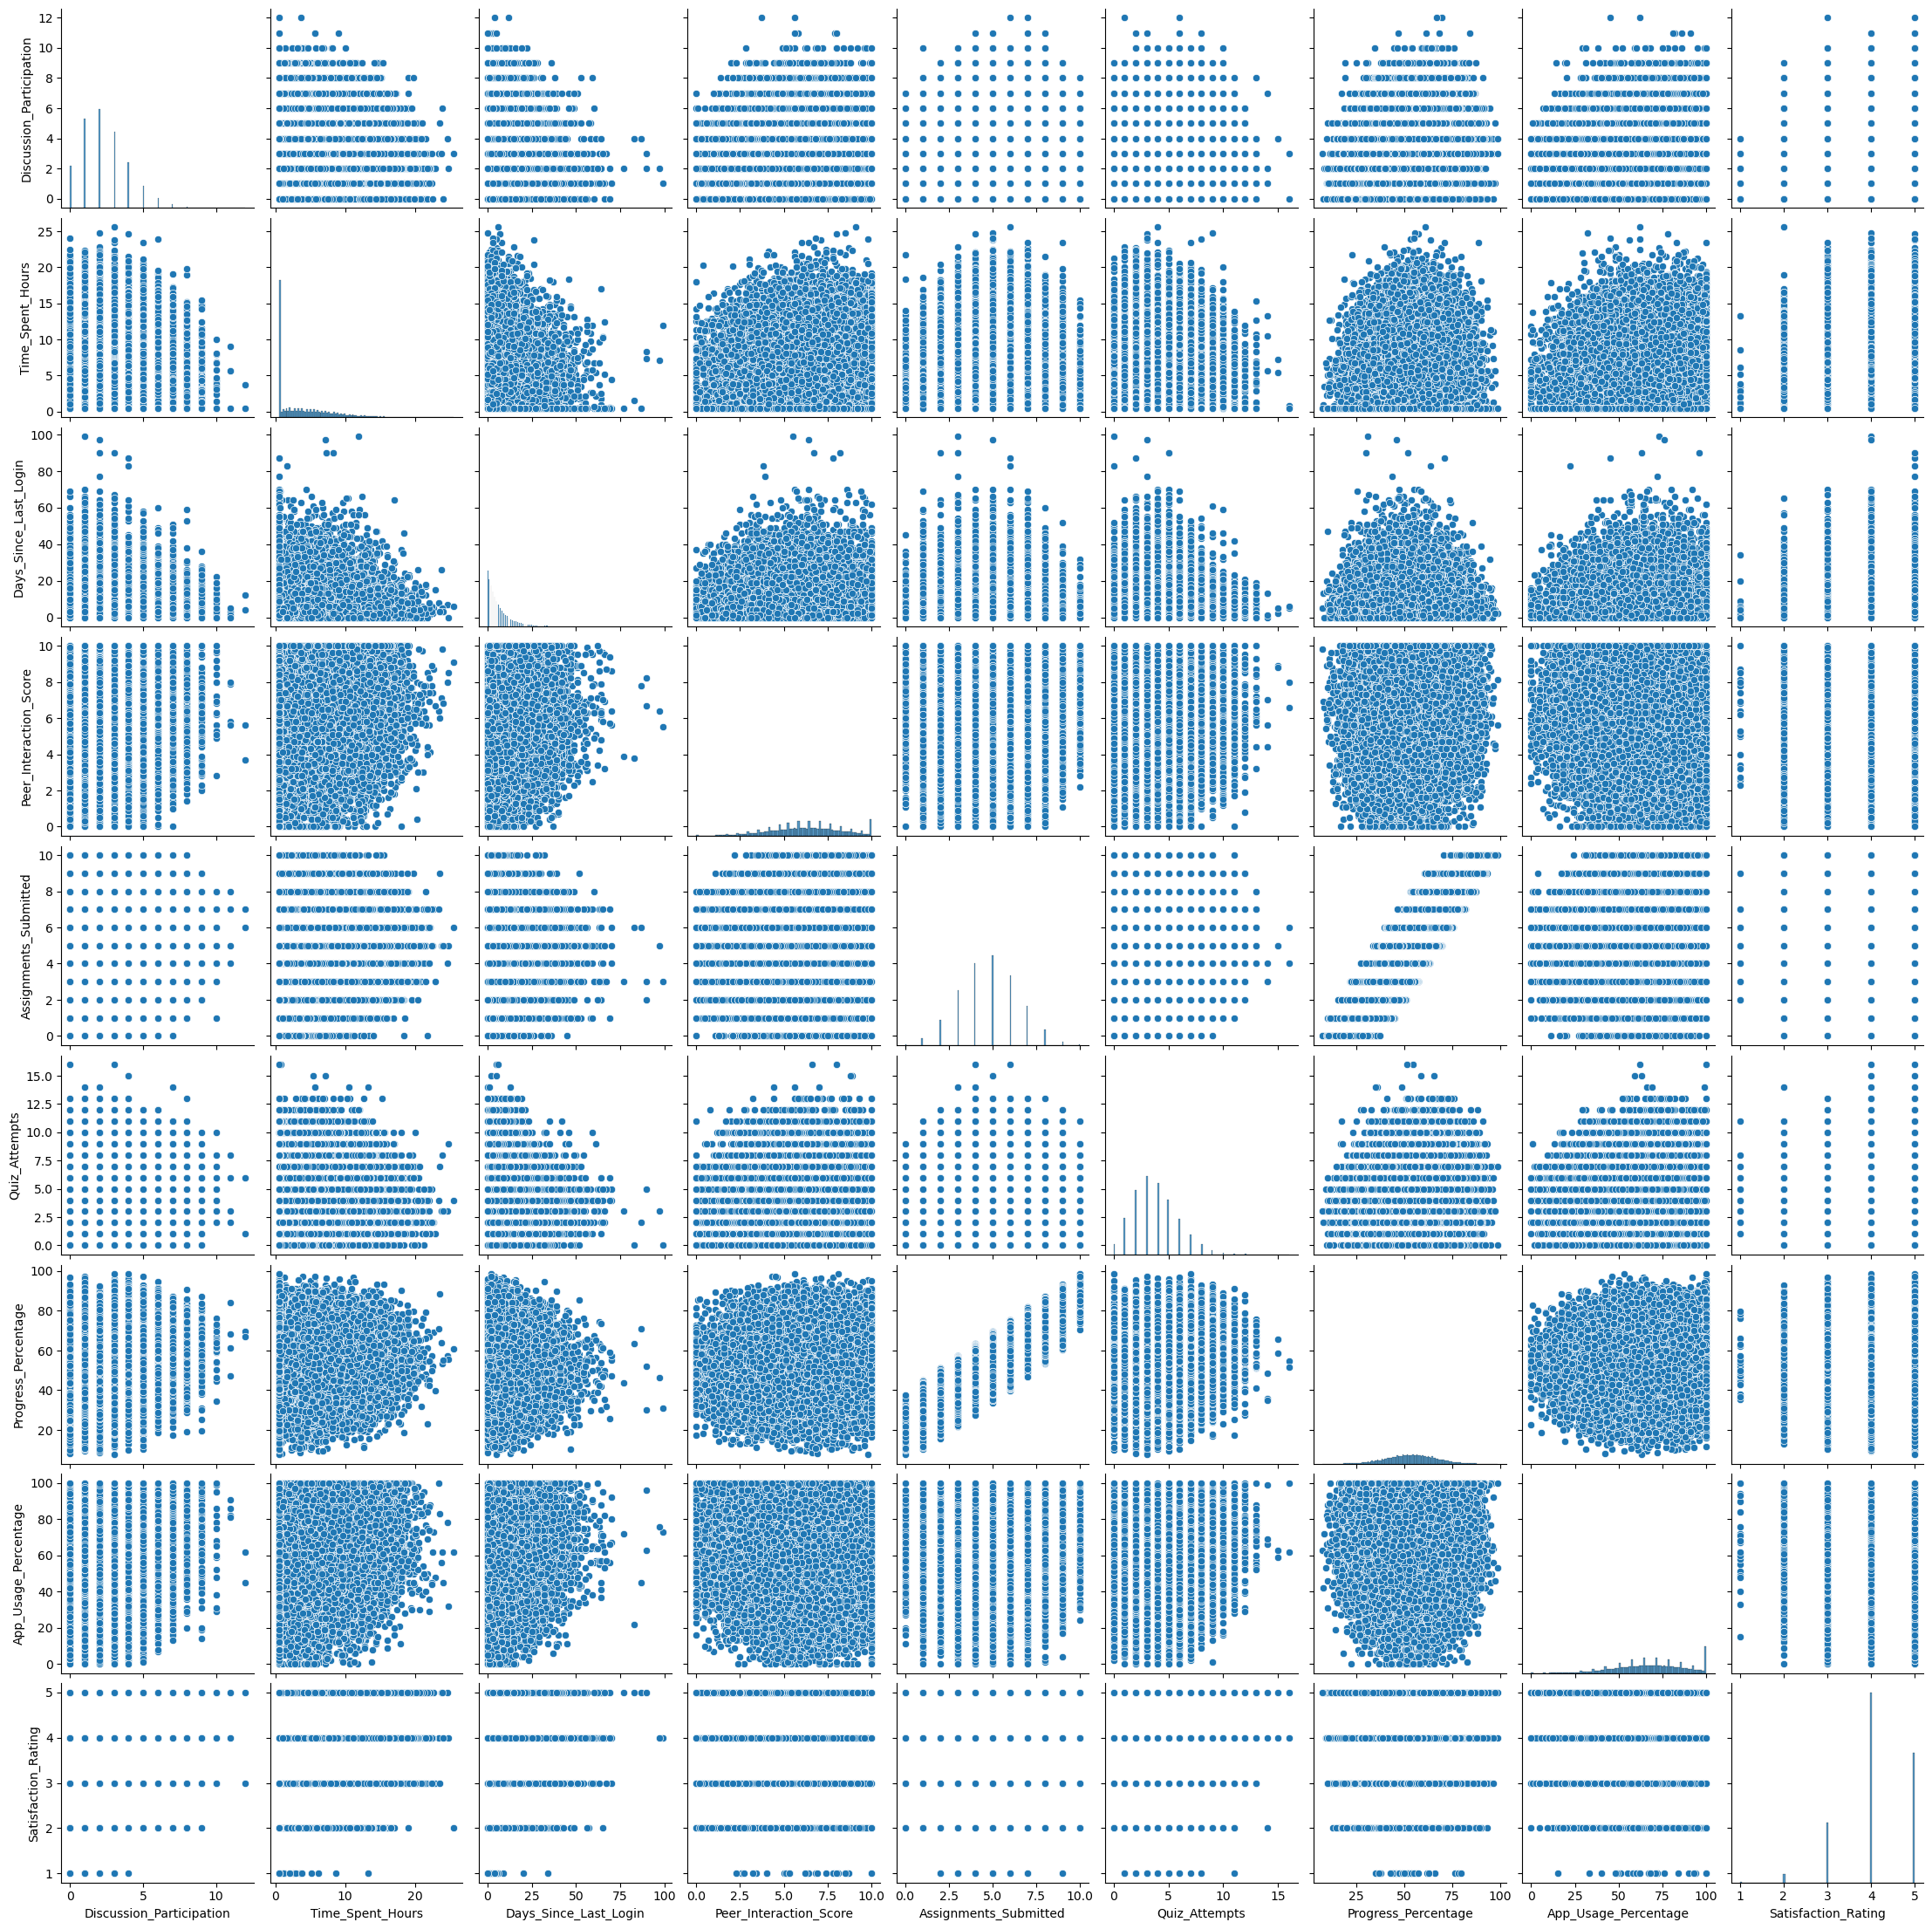

In [ ]:
# visualizing numerical data and looking for any outliers
sns.pairplot(df)

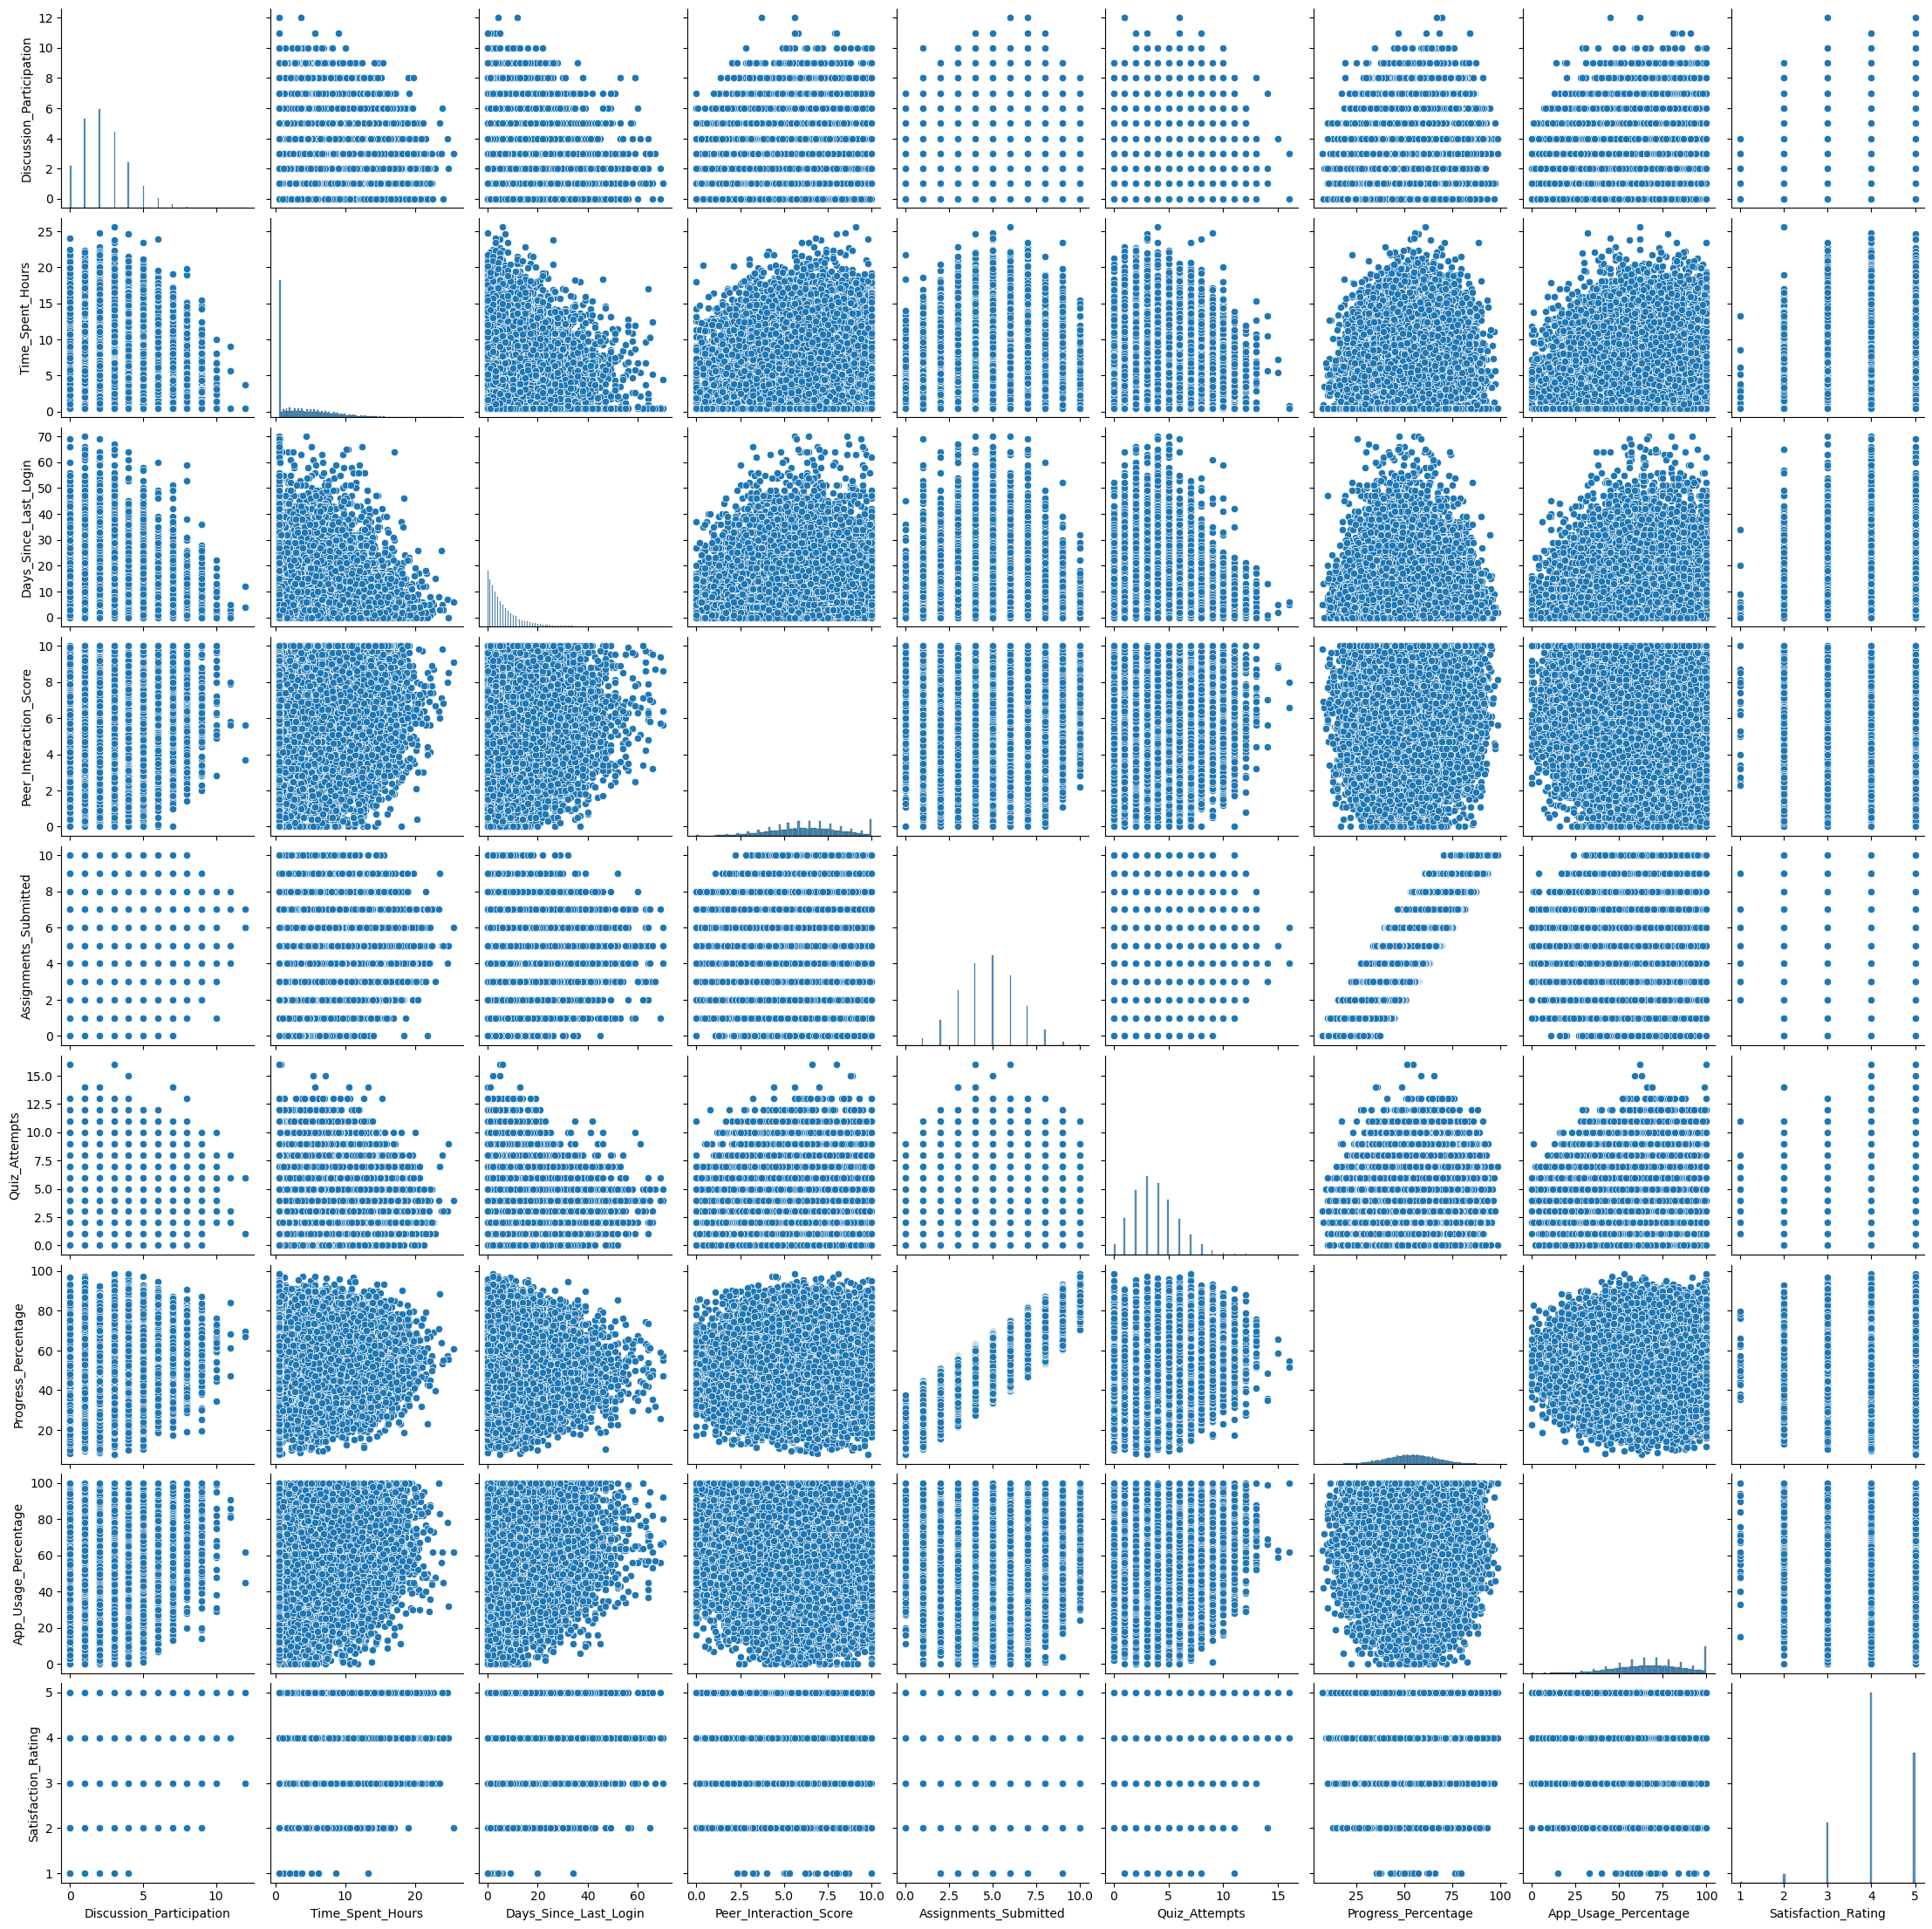

In [ ]:
df=df[df['Days_Since_Last_Login']<75]
sns.pairplot(df)

In [ ]:
df.dtypes.value_counts()


object     17
int64       5
float64     4
Name: count, dtype: int64

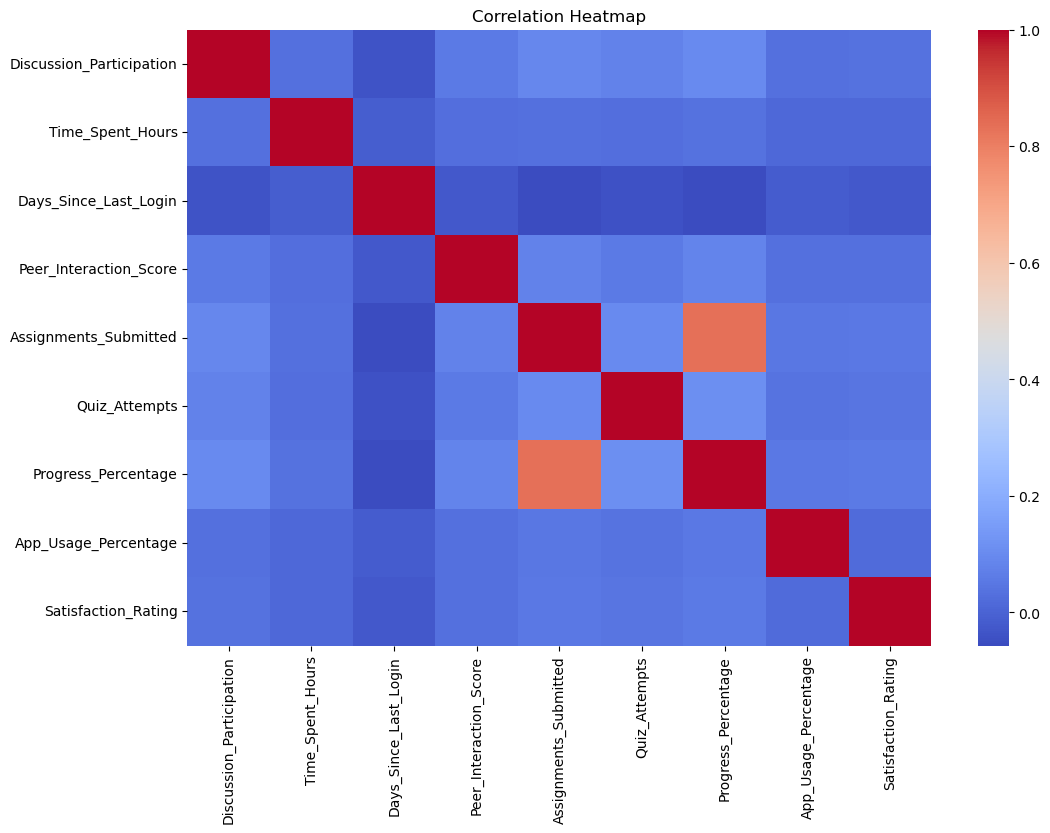

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



### The following copy is used for Model numbers 2 & 3 (df_c):

In [ ]:
df_c=df.copy() # This copy is for Model number 2
df_c2=df.copy() # This copy is for Model number 3

----------------------------------------------------------------------------------------------------

# Model Number 1 (Grp Member: Ateeb Ahmed)

## Preparing data for modeling

In [ ]:
# Identify highly correlated features (corr > 0.85)
corr_matrix = df.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Highly correlated features to remove:", high_corr_features)

Highly correlated features to remove: []


### Multicollinearity Check

I performed a correlation analysis on all numerical features to check for multicollinearity. The goal was to identify any pairs of features with a correlation greater than 0.85, which could negatively impact model stability and interpretability.

**Result:** `high_corr_features = []` - no highly correlated features were found. Therefore, no features needed to be removed for multicollinearity. 

This confirms that the dataset is suitable for modeling without the risk of unstable coefficients due to highly correlated predictors.


### Data Preparation

We prepare the dataset for modeling:

1. Encode categorical variables  
2. Scale numerical features  
3. Split data into training and test sets

In [ ]:
# Drop columns not useful for modeling
df = df.drop(columns=["Student_ID", "Name", "Course_ID", "Course_Name"])

# Encode target variable
df["Completed"] = df["Completed"].map({"Not Completed": 0, "Completed": 1})


### Encode categorical features

- Identify categorical columns
- Apply Label Encoding

In [ ]:
# Identify categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


### Scale numerical features

- Standardize numerical features to mean=0, std=1

In [ ]:
# Identify numerical columns
num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
num_cols.remove("Completed")  # Exclude target

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


### Train-Test Split

- 80% training set, 20% test set
- Stratified split to preserve class balance

In [ ]:
# Features and target
X = df.drop(columns=["Completed"])
y = df["Completed"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (79994, 21)
Test set: (19999, 21)


### Summary

- Categorical features are label-encoded.  
- Target column is numeric (0 / 1).  
- Numerical features are standardized.  
- Dataset split into **80% training** and **20% testing** sets.  

The data is now ready for modeling.


### Model: Logistic Regression

Accuracy: 60.19%

Classification report:
              precision    recall  f1-score   support

           0       0.61      0.62      0.62     10193
           1       0.60      0.58      0.59      9806

    accuracy                           0.60     19999
   macro avg       0.60      0.60      0.60     19999
weighted avg       0.60      0.60      0.60     19999


Confusion matrix:


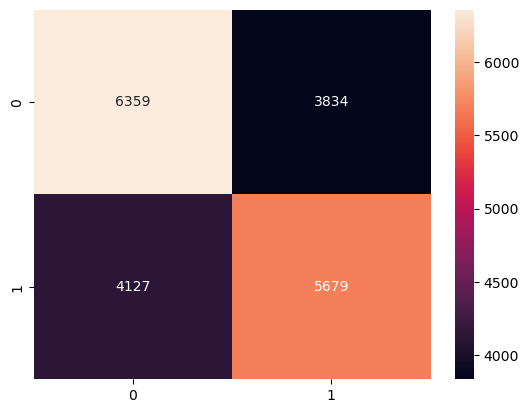

In [ ]:
# Initialize logistic regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

# Predict on test set
y_pred = log_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Accuracy
print("Accuracy: {}%".format(round(accuracy*100, 2)))

# Classification report
print("\nClassification report:")
print(report)

# Confusion matrix
print("\nConfusion matrix:")
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

### Logistic Regression Model

A Logistic Regression model was trained to predict whether a student would complete the course. Logistic regression is a widely used classification method that models the probability of a binary outcome.

The model was trained on 80% of the dataset and tested on the remaining 20%. Categorical variables were label-encoded, numerical variables were standardized, and irrelevant identifier columns were removed during preprocessing. Logistic Regression works well with this type of prepared data.

Performance was evaluated using accuracy, confusion matrix, and a classification report including precision, recall, and F1-score. The model achieved an **accuracy of 60.19%**, with the confusion matrix:

[[6359 3834]
[4127 5679]]

# Model Number 2 (Grp Member: Mohammed Hammoud)

### Multicollinearity Check (Using VIF)

In [ ]:
# Keep only numeric columns
X = df_c.select_dtypes(include=['number'])

# Add constant for intercept
X = add_constant(X)

# Calculate VIFs
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_values = []
for i in range(X.shape[1]):
    vif = variance_inflation_factor(X.values, i)
    vif_values.append(vif)

vif_data["VIF"] = vif_values
# VIF's of numerical features
print(vif_data)


                    feature        VIF
0                     const  70.764824
1  Discussion_Participation   1.019555
2          Time_Spent_Hours   1.003223
3     Days_Since_Last_Login   1.006688
4    Peer_Interaction_Score   1.013529
5     Assignments_Submitted   3.274221
6             Quiz_Attempts   1.022334
7       Progress_Percentage   3.290273
8      App_Usage_Percentage   1.005574
9       Satisfaction_Rating   1.006912


### Summary: 

- Selected only numeric predictors from the dataset  
- Added a constant term for regression intercept  
- Computed Variance Inflation Factor (VIF) for each feature  
- All VIF values < 10 → no multicollinearity concerns among numerical variables
#### Numerical features showed low VIF values(<10), indicating no multicollinearity concerns accross them.

## Next, categorical columns:

In [ ]:
# categorical columns
categorical_cols = df_c.select_dtypes(include=['object','category']).columns
print("Categorical columns:", categorical_cols.tolist())

Categorical columns: ['Student_ID', 'Name', 'Gender', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_ID', 'Course_Name', 'Category', 'Course_Level', 'Enrollment_Date', 'Payment_Mode', 'Fee_Paid', 'Discount_Used', 'Completed']


In [ ]:
#unique values
for col in categorical_cols:
    print(col, df_c[col].nunique())

Student_ID 99993
Name 300
Gender 3
Education_Level 5
Employment_Status 4
City 15
Device_Type 3
Internet_Connection_Quality 3
Course_ID 8
Course_Name 8
Category 5
Course_Level 3
Enrollment_Date 721
Payment_Mode 6
Fee_Paid 2
Discount_Used 2
Completed 2


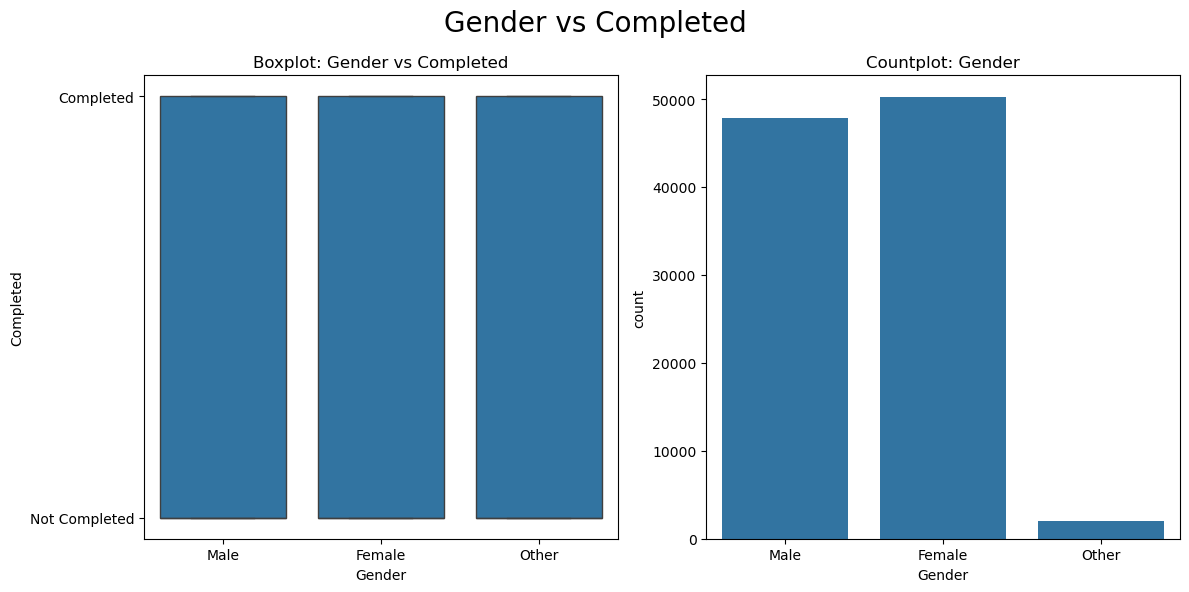

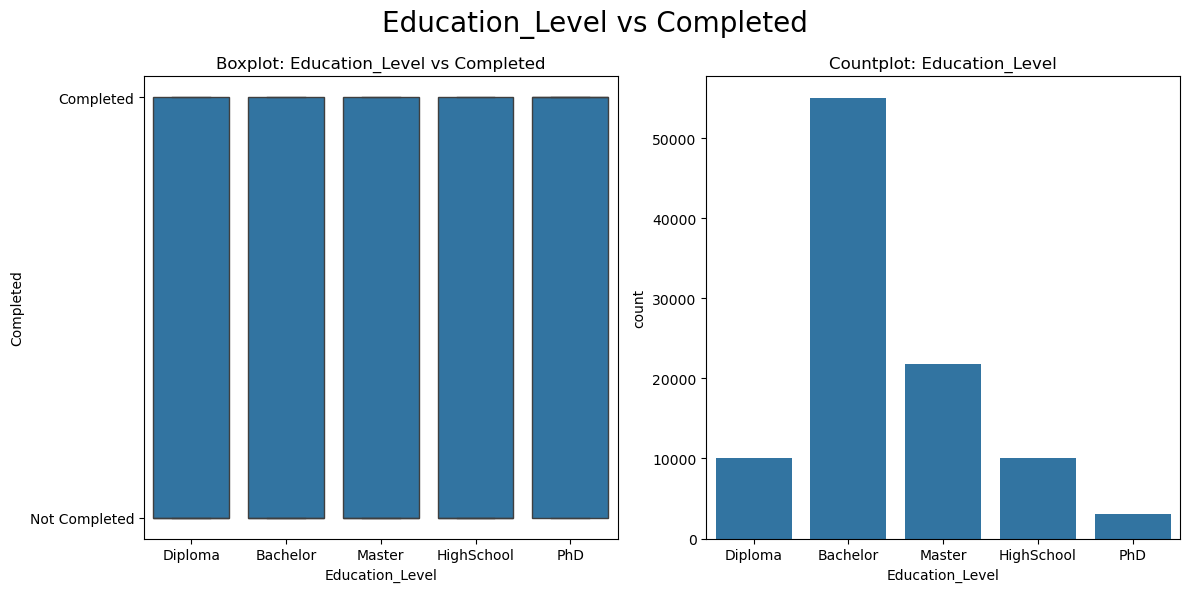

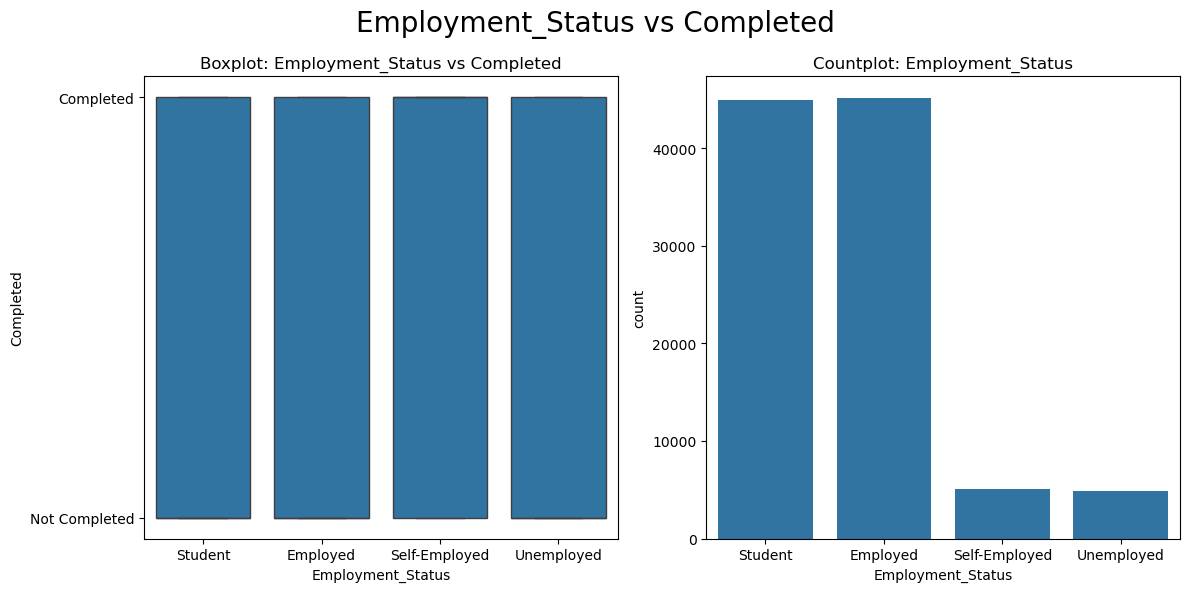

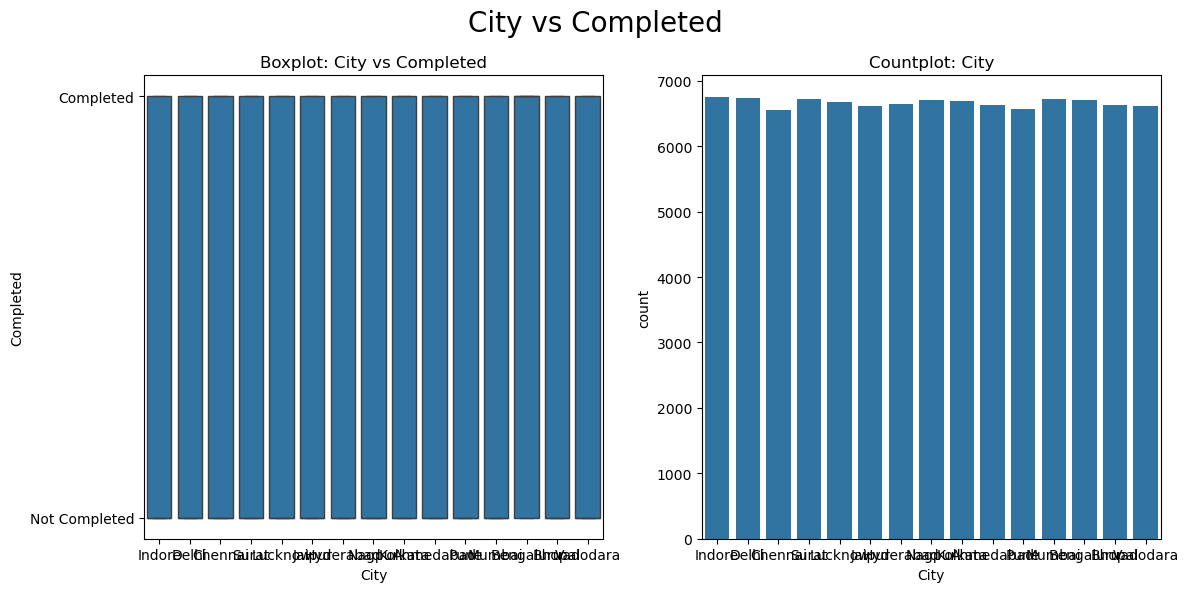

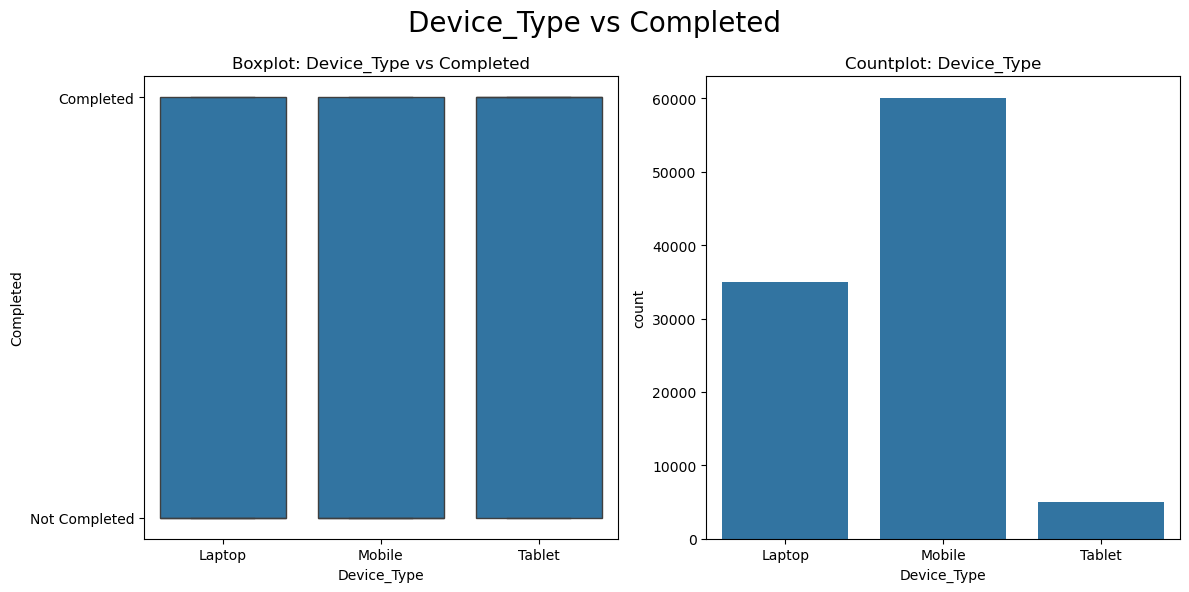

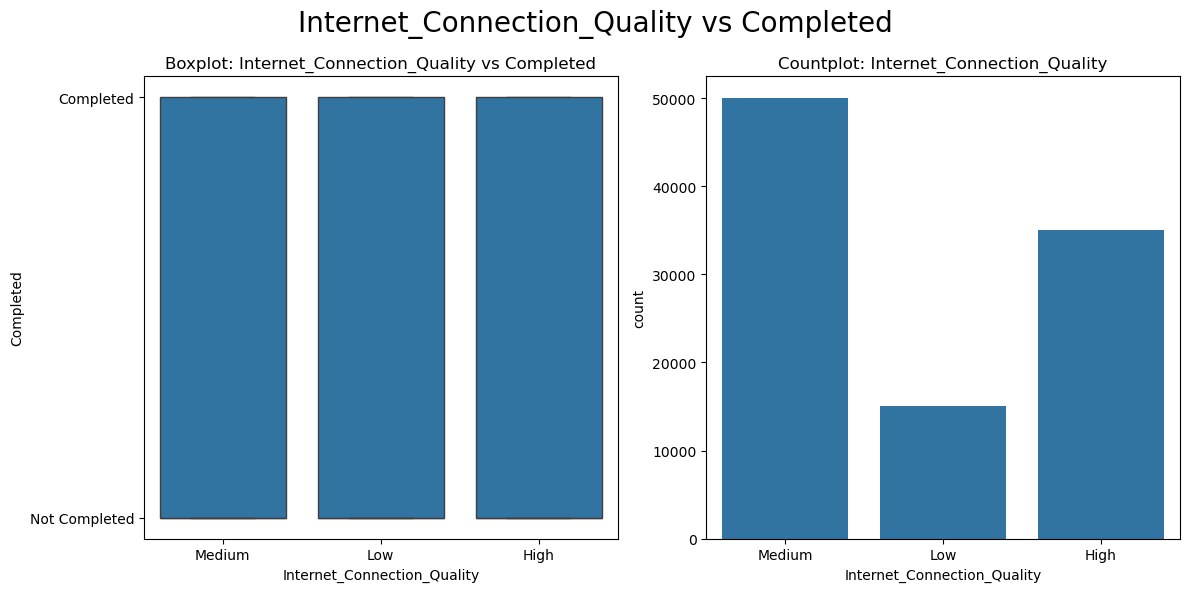

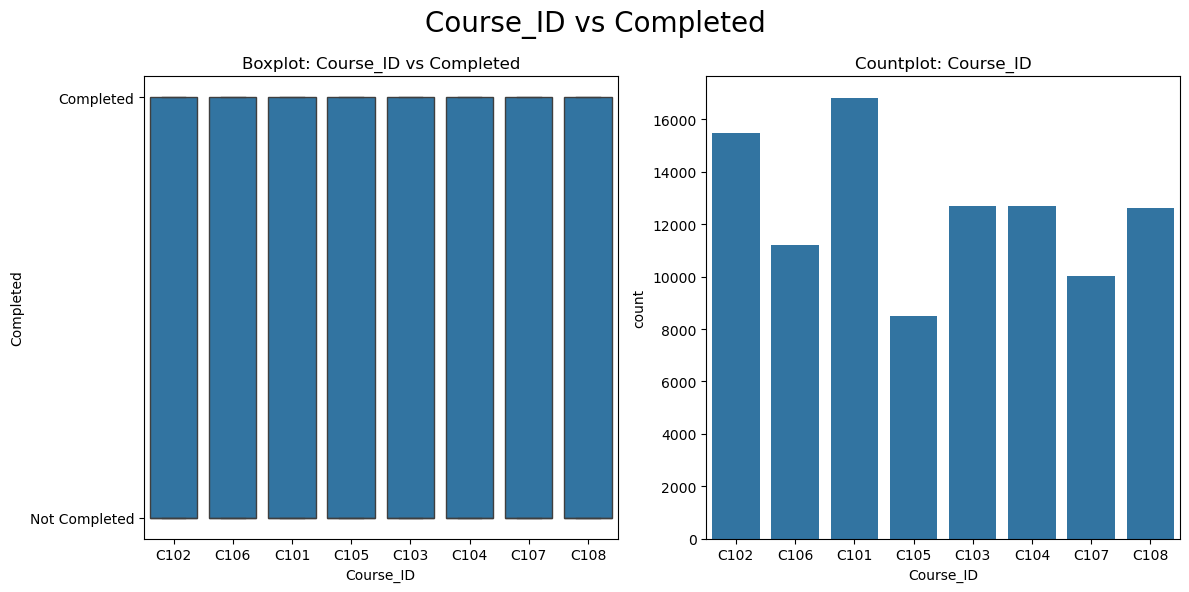

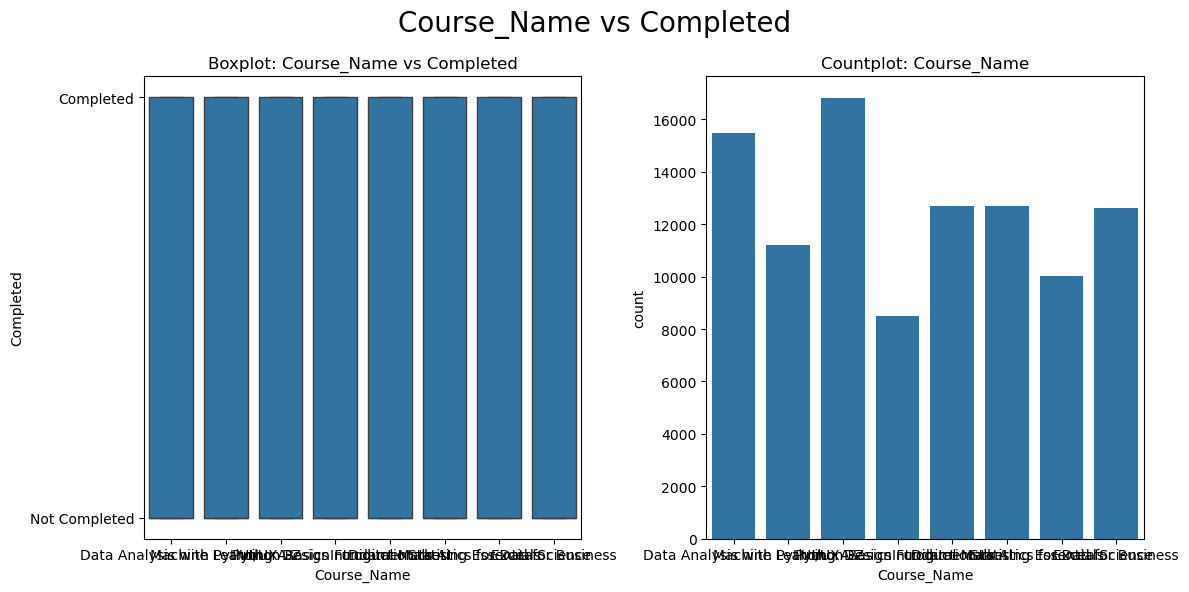

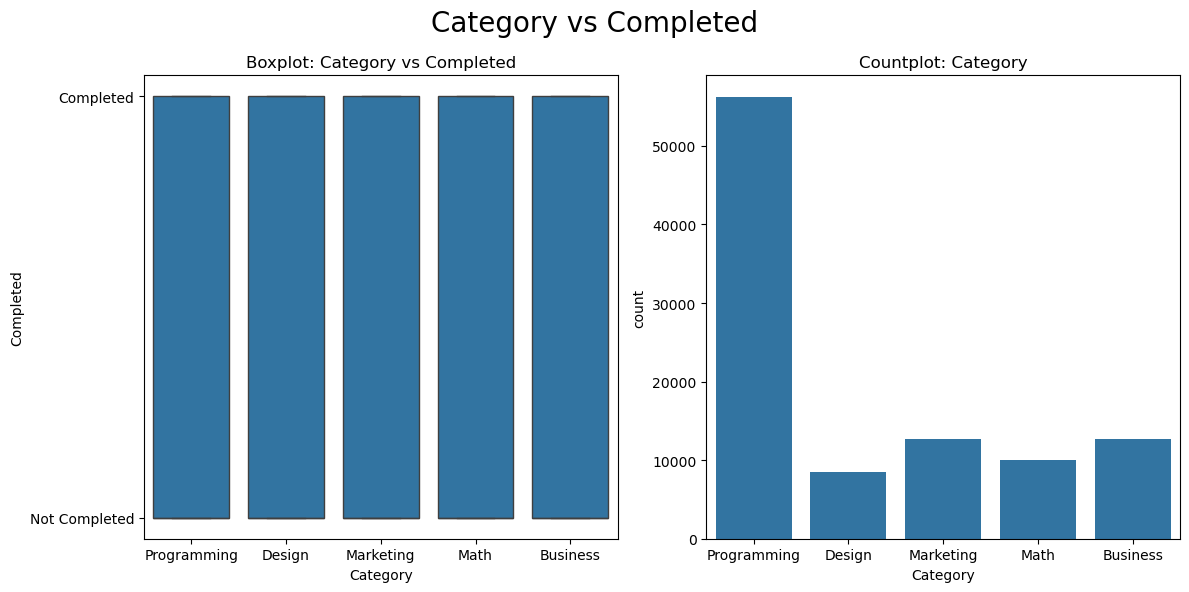

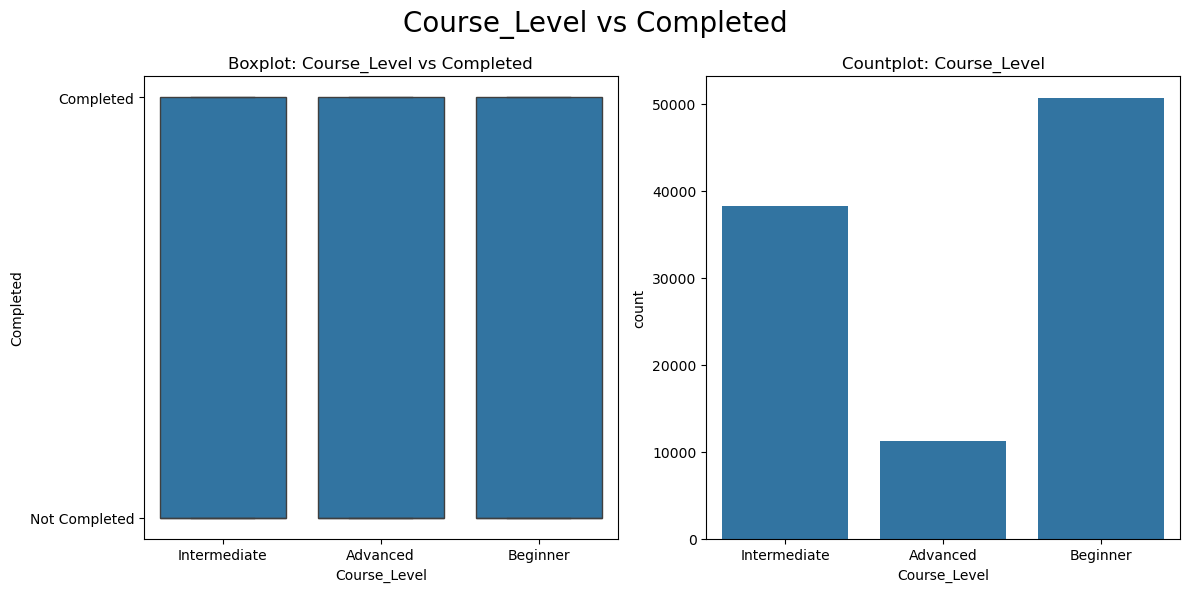

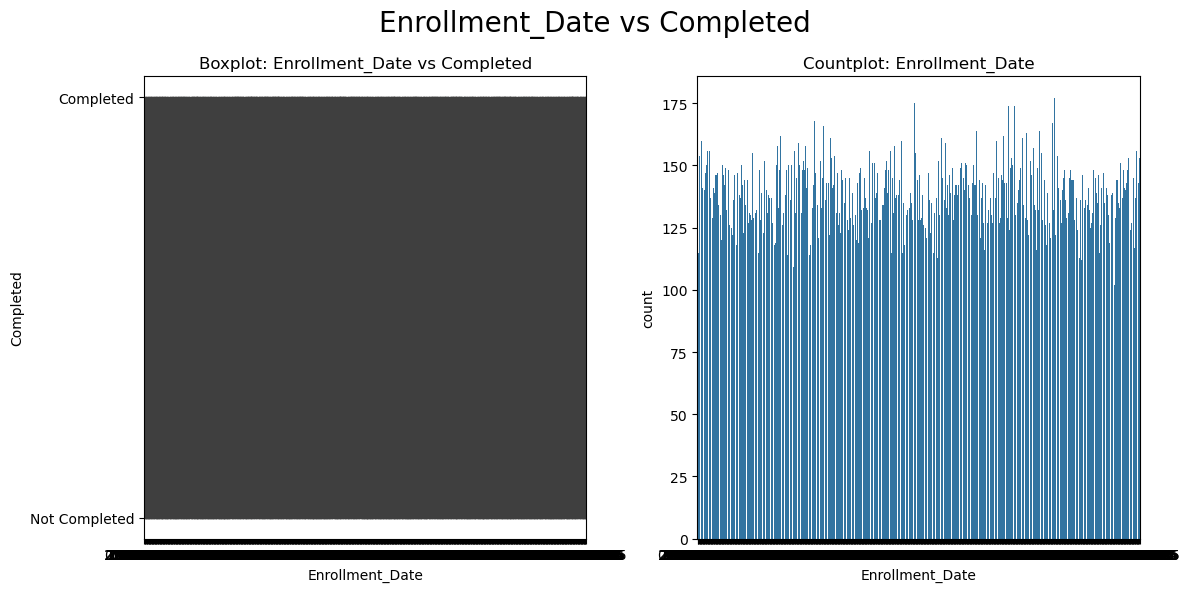

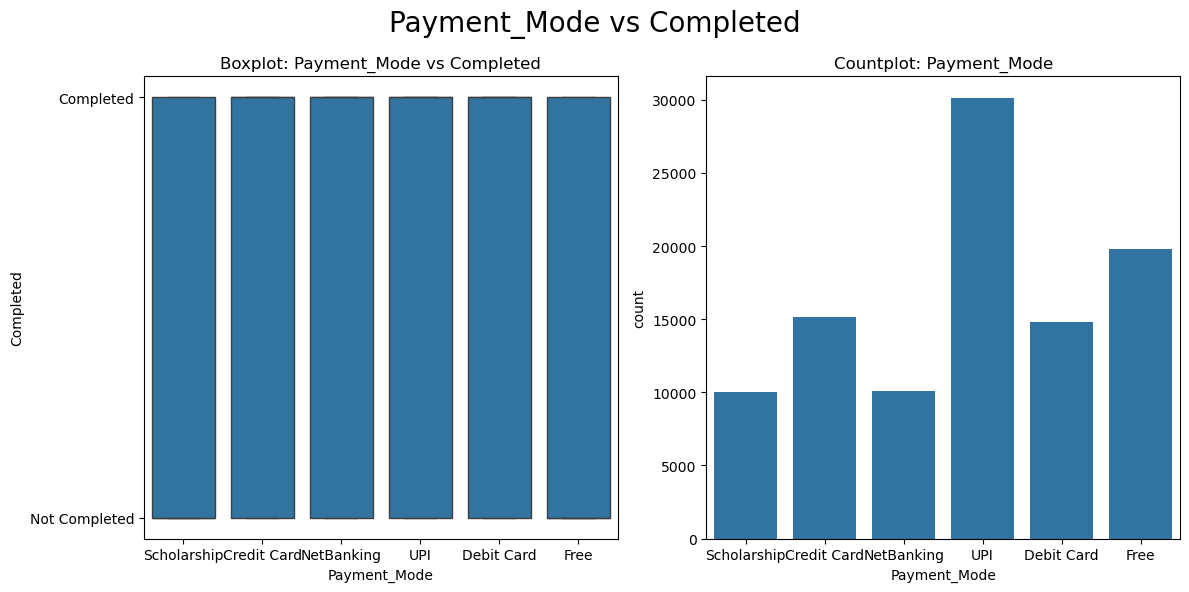

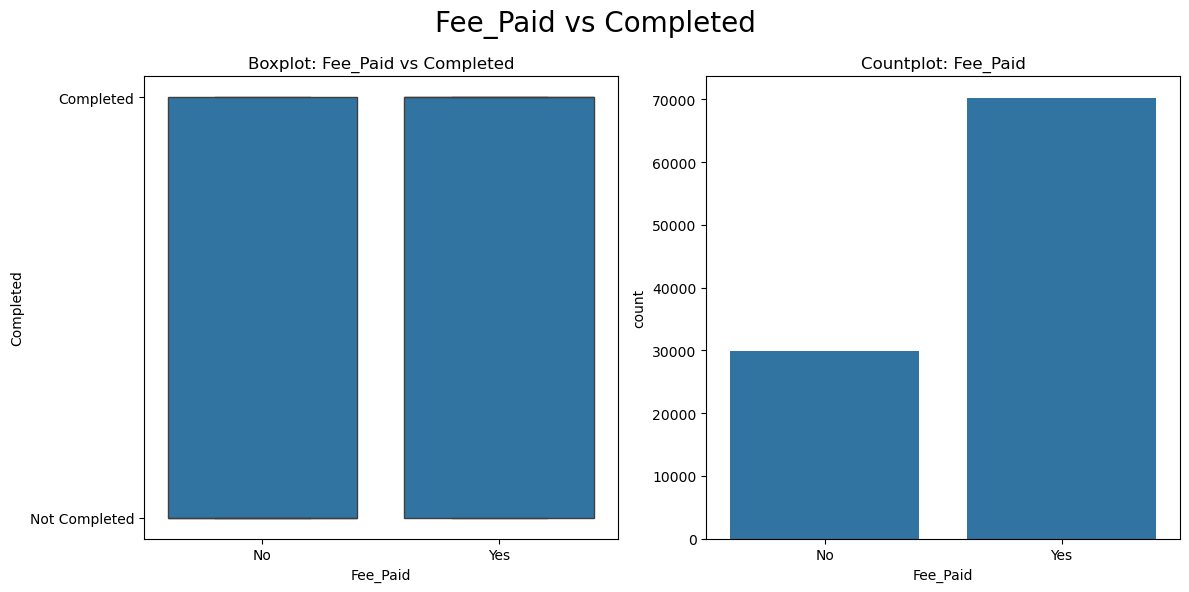

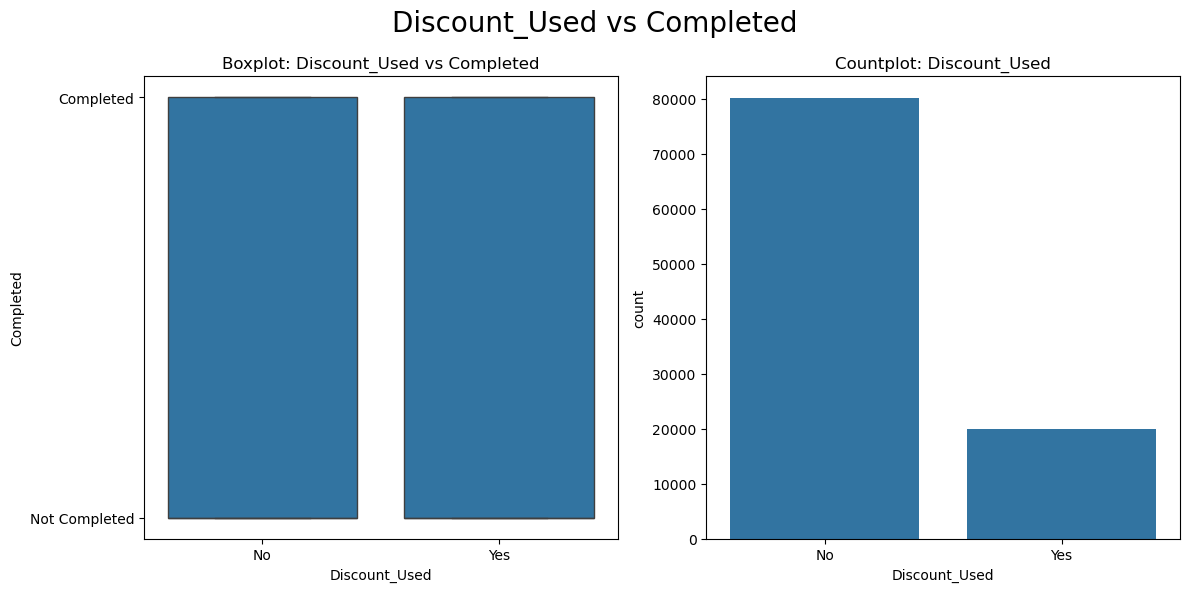

In [ ]:
## looking visually at categorical features

# Get categorical features
# Student_ID, and Name features sounds like they are redundant,i will drop them
categorical_features = df_c.drop(columns={'Completed','Name','Student_ID'}).select_dtypes(include=['object']).columns

for col in categorical_features:
    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    fig.suptitle(f"{col} vs Completed", fontsize=20)

    # Boxplot: categorical vs target
    sns.boxplot(x=col, y="Completed", data=df_c, ax=ax[0])
    ax[0].set_title(f"Boxplot: {col} vs Completed")

    # Countplot: distribution of categories
    sns.countplot(x=col, data=df_c, ax=ax[1])
    ax[1].set_title(f"Countplot: {col}")

    plt.tight_layout()
    plt.show()

### With a categorical target ('Completed'), we want evaluate categorical predictors numerically. The goal is to remove redundant categorical features that don’t show a meaningful relationship.
### I will apply the Chi-Square test of independence between each categorical feature and the target.
### Hypothesis testing framework:
   - H0: Feature is independent of the target (no association).
   - H1: Feature is associated with the target.
### Decision rule:
   - If p-value > 0.05 → fail to reject H0 → feature not significantly related → candidate to drop.
   - If p-value ≤ 0.05 → reject H0 → feature significantly related → keep.
### This way i automatically prune categorical variables that don’t contribute to predicting 'Completed'.

In [ ]:

# Candidate categorical columns (object dtype)
# Track which columns to drop
# initially i dropped Student_ID and Name
drop_cols = ['Student_ID', 'Name']

for col in categorical_features:
    # Build a contingency table (cross-tabulation of counts)
    # Rows = categories of the feature, Columns = categories of the target
    contingency = pd.crosstab(df_c[col], df_c['Completed'])
    
    # Apply Chi-Square test to check independence
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    
    if p > 0.05:
        # Not significantly associated; feature to drop
        print(f"{col}: Chi2={chi2:.2f}, p-value={p:.4f} --> Not significantly associated with Completed (candidate to drop)")
        drop_cols.append(col)
    else:
        # Significantly associated; keep it
        print(f"{col}: Chi2={chi2:.2f}, p-value={p:.4f} --> Significantly associated with Completed (keep)")

# Drop the non-significant categorical columns
df_reduced = df_c.drop(columns=drop_cols)

print("\nDropped columns:", drop_cols)
print("Remaining shape:", df_reduced.shape)

# df.shape shows the original dataset dimensions for comparison
df_c.shape

Gender: Chi2=6.70, p-value=0.0351 --> Significantly associated with Completed (keep)
Education_Level: Chi2=12.74, p-value=0.0126 --> Significantly associated with Completed (keep)
Employment_Status: Chi2=45.15, p-value=0.0000 --> Significantly associated with Completed (keep)
City: Chi2=14.03, p-value=0.4475 --> Not significantly associated with Completed (candidate to drop)
Device_Type: Chi2=10.47, p-value=0.0053 --> Significantly associated with Completed (keep)
Internet_Connection_Quality: Chi2=73.41, p-value=0.0000 --> Significantly associated with Completed (keep)
Course_ID: Chi2=1.37, p-value=0.9865 --> Not significantly associated with Completed (candidate to drop)
Course_Name: Chi2=1.37, p-value=0.9865 --> Not significantly associated with Completed (candidate to drop)
Category: Chi2=0.89, p-value=0.9254 --> Not significantly associated with Completed (candidate to drop)
Course_Level: Chi2=0.16, p-value=0.9217 --> Not significantly associated with Completed (candidate to drop)


(99993, 26)

In [ ]:
df_reduced.columns
df_reduced.dtypes.count()
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99993 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       99993 non-null  object 
 1   Education_Level              99993 non-null  object 
 2   Employment_Status            99993 non-null  object 
 3   Device_Type                  99993 non-null  object 
 4   Internet_Connection_Quality  99993 non-null  object 
 5   Discussion_Participation     99993 non-null  int64  
 6   Time_Spent_Hours             99993 non-null  float64
 7   Days_Since_Last_Login        99993 non-null  int64  
 8   Peer_Interaction_Score       99993 non-null  float64
 9   Assignments_Submitted        99993 non-null  int64  
 10  Quiz_Attempts                99993 non-null  int64  
 11  Progress_Percentage          99993 non-null  float64
 12  Payment_Mode                 99993 non-null  object 
 13  Fee_Paid             

In [ ]:
df_reduced

,Gender,Education_Level,Employment_Status,Device_Type,Internet_Connection_Quality,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Peer_Interaction_Score,Assignments_Submitted,Quiz_Attempts,Progress_Percentage,Payment_Mode,Fee_Paid,App_Usage_Percentage,Satisfaction_Rating,Completed
0,Male,Diploma,Student,Laptop,Medium,2,0.5,1,4.3,8,5,70.8,Scholarship,No,49,4.0,Completed
1,Female,Bachelor,Student,Laptop,Low,2,0.9,3,7.8,4,3,55.6,Credit Card,Yes,86,4.0,Not Completed
2,Female,Master,Student,Mobile,Medium,3,0.5,19,6.7,8,3,78.8,NetBanking,Yes,85,5.0,Completed
3,Female,Diploma,Employed,Mobile,High,1,7.4,19,6.4,0,4,24.7,UPI,Yes,42,4.0,Completed
4,Female,Master,Self-Employed,Laptop,Medium,1,0.5,4,7.5,5,8,64.9,Debit Card,Yes,91,4.0,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Female,Bachelor,Student,Mobile,Medium,4,7.7,6,4.3,6,2,72.0,UPI,Yes,100,4.0,Completed
99996,Female,Bachelor,Self-Employed,Mobile,High,5,0.5,9,8.4,5,6,62.7,UPI,Yes,71,3.0,Not Completed
99997,Male,Master,Employed,Laptop,Medium,0,5.8,16,7.3,5,3,57.1,UPI,Yes,61,4.0,Not Completed
99998,Female,Bachelor,Student,Mobile,High,1,5.7,3,5.4,5,10,47.4,Credit Card,Yes,78,5.0,Not Completed


## Target Labeling & Categorical Encoding

- Relabeling target column numerically:  
  - Completed : 1  
  - Not Completed : 0  
- Ensures target is intuitive (1 = success, 0 = failure)  
- Applied `get_dummies` to handle categorical features (drop_first=True)  
- Produced `df2` with numeric and dummy‑encoded variables ready for modeling

In [ ]:
# Target column
df_reduced['Completed'] = df_reduced['Completed'].map({'Completed': 1, 'Not Completed': 0}).astype('int64')

# deal with categorical features; get_dummies
df2 = pd.get_dummies(df_reduced, drop_first=True)
df2

,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Peer_Interaction_Score,Assignments_Submitted,Quiz_Attempts,Progress_Percentage,App_Usage_Percentage,Satisfaction_Rating,Completed,...,Device_Type_Mobile,Device_Type_Tablet,Internet_Connection_Quality_Low,Internet_Connection_Quality_Medium,Payment_Mode_Debit Card,Payment_Mode_Free,Payment_Mode_NetBanking,Payment_Mode_Scholarship,Payment_Mode_UPI,Fee_Paid_Yes
0,2,0.5,1,4.3,8,5,70.8,49,4.0,1,...,False,False,False,True,False,False,False,True,False,False
1,2,0.9,3,7.8,4,3,55.6,86,4.0,0,...,False,False,True,False,False,False,False,False,False,True
2,3,0.5,19,6.7,8,3,78.8,85,5.0,1,...,True,False,False,True,False,False,True,False,False,True
3,1,7.4,19,6.4,0,4,24.7,42,4.0,1,...,True,False,False,False,False,False,False,False,True,True
4,1,0.5,4,7.5,5,8,64.9,91,4.0,1,...,False,False,False,True,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,4,7.7,6,4.3,6,2,72.0,100,4.0,1,...,True,False,False,True,False,False,False,False,True,True
99996,5,0.5,9,8.4,5,6,62.7,71,3.0,0,...,True,False,False,False,False,False,False,False,True,True
99997,0,5.8,16,7.3,5,3,57.1,61,4.0,0,...,False,False,False,True,False,False,False,False,True,True
99998,1,5.7,3,5.4,5,10,47.4,78,5.0,0,...,True,False,False,False,False,False,False,False,False,True


### Logistic Regression

(99993, 28) (99993, 1)
Accuracy score test 0.6034641385655426
Accuracy score train 0.6035416166626664


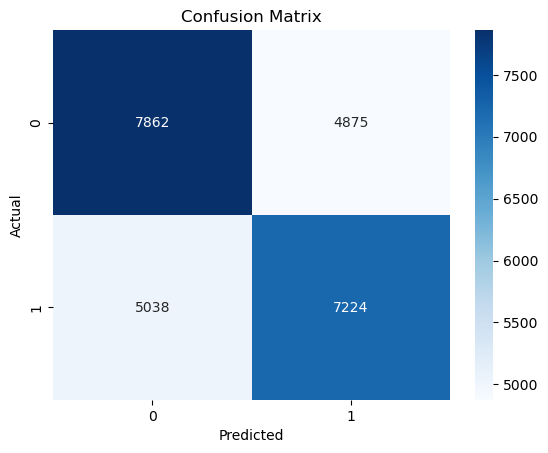

              precision    recall  f1-score   support

           0       0.61      0.62      0.61     12737
           1       0.60      0.59      0.59     12262

    accuracy                           0.60     24999
   macro avg       0.60      0.60      0.60     24999
weighted avg       0.60      0.60      0.60     24999



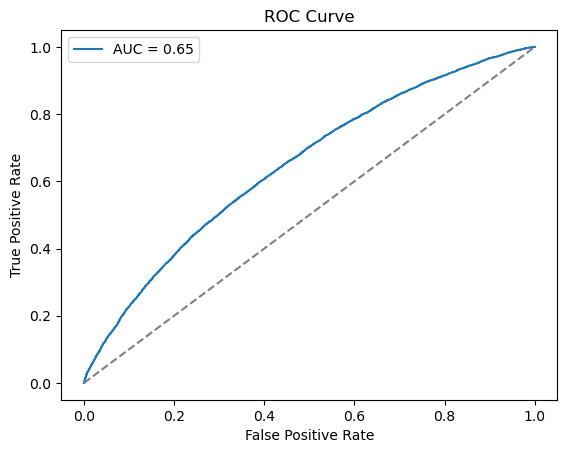

In [ ]:
# Target and feature shaping
X = np.array(df2.drop(columns={'Completed'}))
Y = np.array(df2["Completed"]).reshape(-1,1)
print(X.shape, Y.shape)

#train_test_split, test_size set to 0.25

xtr, xte, ytr, yte = train_test_split(X, Y, test_size=.25)

# Pipeline: standardization + logistic regression
# set max_iteration for the Gradient Descent
pipe = Pipeline([
    ('scaler', StandardScaler()),                   # standarize features 
    ('logreg', LogisticRegression(max_iter=1000)) # classifier
])

# Fit model
pipe.fit(xtr, ytr.ravel())

# Evaluate (metrics)
#accuracy, confusion_matrix, classification_report
pipe.score(xtr, ytr)

ypred=pipe.predict(xte)

print('Accuracy score test', accuracy_score(ypred, yte))
print('Accuracy score train', accuracy_score(ytr, pipe.predict(xtr)))

cm = confusion_matrix(yte, ypred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(yte, ypred))

#plot roc_curve, roc_auc_score

yprob = pipe.predict_proba(xte)[:,1]  # probability of class 1
fpr, tpr, thresholds = roc_curve(yte, yprob)
auc = roc_auc_score(yte, yprob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Predictive Model: Logistic Regression with Standardization

### I chose **Logistic Regression** to predict student who have completed online courses from who did not because the target variable is binary (`Completed` vs `Not Completed`), and logistic regression is a   well‑established baseline classifier for categorical outcomes. To ensure fair comparison across features, I standardized predictors using `StandardScaler` inside a pipeline, which prevents data leakage and keeps preprocessing consistent.

**Evaluation Metrics:**
- 1.Accuracy: Measures overall correctness of predictions.
-   The logistic regression model achieved an overall accuracy of ~60%, with almost  balanced precision and recall across both classes (Completed and Not Completed).

- 2.Confusion Matrix: Shows distribution of true positives, true negatives, false positives, and false negatives.

- 3.Classification Report: Provides precision, recall, and F1‑score for each class, highlighting imbalances.
-   The F1-scores are nearly identical , indicating consistent performance without favoring one class.

- 4.ROC Curve & AUC: Visualizes trade‑offs between sensitivity and specificity, with AUC summarizing discriminative power.
-   The ROC curve shows an AUC around 0.65, suggesting moderate discriminative ability - the model is better than random guessing but not highly confident in separating the two classes.


### Generally this model serves as a reasonable baseline, but further improvements (like alternative classifiers) may be needed to boost recall for the Not Completed group.



## Model Number 3 (Grp member: Malith Wettasinghe )

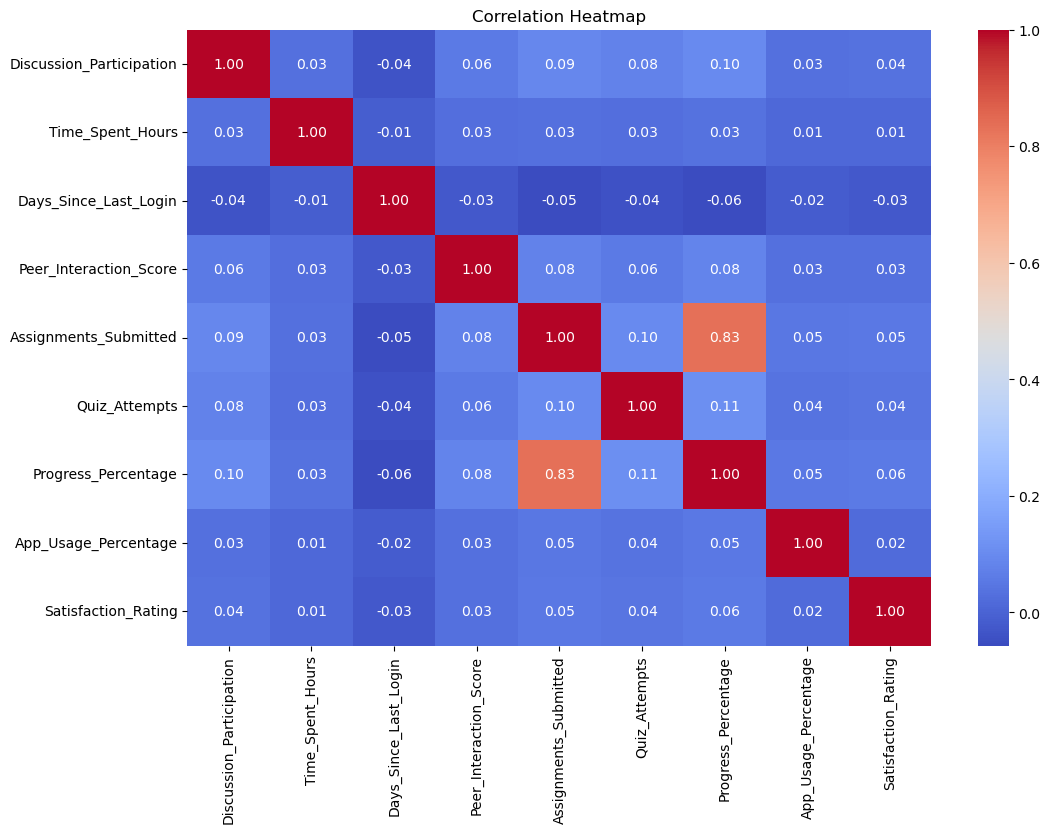

In [ ]:
## visualizing some correlation using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_c2.select_dtypes(include=['number']).corr(), annot=True , fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Features and Target:

In [ ]:
# Features selected after EDA
features = [
    'Progress_Percentage',
    'Assignments_Submitted',
    'Quiz_Attempts',
    'Satisfaction_Rating'
]

X = np.array(df_c2[features])
y = np.array(df_c2['Completed']).reshape(-1,1)

#

## Training Model: Logistic Regression

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train.ravel())

# Predictions
y_pred = model_lr.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)

print("Logistic Regression – Engagement-Based Completion Model")
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred))

# Coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_lr.coef_[0],
    'Abs_Coefficient': np.abs(model_lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance (Log-Odds):")
print(coef_df.round(4))
print(f"\nIntercept: {model_lr.intercept_[0]:.4f}")

Logistic Regression – Engagement-Based Completion Model
Accuracy: 0.5927

               precision    recall  f1-score   support

    Completed       0.59      0.57      0.58      9806
Not Completed       0.60      0.61      0.60     10193

     accuracy                           0.59     19999
    macro avg       0.59      0.59      0.59     19999
 weighted avg       0.59      0.59      0.59     19999


Feature Importance (Log-Odds):
                 Feature  Coefficient  Abs_Coefficient
1  Assignments_Submitted       0.1345           0.1345
0    Progress_Percentage      -0.0507           0.0507
3    Satisfaction_Rating      -0.0074           0.0074
2          Quiz_Attempts      -0.0018           0.0018

Intercept: 2.1641


Logistic Regression was selected because the target variable (Completed) is binary. Exploratory analysis showed that engagement and progress-related variables had the strongest relationship with completion outcomes.

Approach:
Rather than using all available features, this model focuses on high-signal behavioral variables to improve interpretability and reduce noise.

Evaluation:
Performance was assessed using accuracy and class-based precision/recall. Coefficients were examined to understand which engagement behaviors most strongly influenced completion likelihood.

Key Insight:
Progress percentage and assignment submission were the strongest predictors, reinforcing the importance of sustained engagement over demographic factors.

----------------------------------------------------------------------------------------------------

## Overall Conclusion: Best Model

All three team members implemented **Logistic Regression models** to predict course completion, which is an appropriate and reasonable choice given the **binary nature of the target variable** (*Completed vs Not Completed*). Across all implementations, model performance was **consistent**, with test accuracies ranging from **~59% to ~60%**, balanced precision and recall for both classes, and **no signs of overfitting** (training and testing accuracies were nearly identical).

### Best Model Choice

Among the three approaches, **Team Member 2’s Logistic Regression with Standardization** is the **best overall model** for this project.

### Justification

- It achieved the **highest test accuracy (~60.35%)** among all models.  
- The use of a **pipeline with `StandardScaler`** ensures proper preprocessing and avoids **data leakage**, making the model more **robust and methodologically sound**.  
- Performance metrics (**accuracy, F1-score, ROC-AUC ≈ 0.65**) indicate **moderate but reliable discriminative ability**, slightly outperforming the other implementations.  
- **Balanced precision and recall** show that the model does not favor one class over the other, which is important for fair prediction of both **completed** and **non-completed** students.

While **Team Member 1’s model** provided strong **interpretability** through feature coefficients and **Team Member 3’s model** offered clear **confusion matrix insights**, their predictive performance was **marginally lower** and preprocessing was **less comprehensive**.

### Key Insights Across Models

- **Engagement-related variables** (such as **assignment submissions** and **progress percentage**) consistently emerged as the **strongest predictors** of course completion.  
- Logistic Regression performed **better than random guessing**, but overall accuracy remained limited, suggesting that the relationship between student behavior and completion is **not purely linear**.  
- The **similar results across models** indicate that performance is constrained more by **data complexity** than by modeling choices.

### Final Assessment

Overall, **Logistic Regression** proved to be a **reasonable and interpretable baseline model** for this classification task. Among the tested approaches, **Logistic Regression with Standardization** is the **most reliable and methodologically sound choice**, while future experimentation with **more advanced models** may lead to stronger predictive performance.
